# 합성곱 신경망의 시각화

<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hg-mldl2/blob/main/08-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

In [3]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
import keras
import tensorflow as tf

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

## 가중치 시각화

In [4]:
# 코랩에서 실행하는 경우에는 다음 명령을 실행하여 best-cnn-model.keras 파일을 다운로드받아 사용하세요.
!wget https://github.com/rickiepark/hg-mldl2/raw/main/best-cnn-model.keras

'wget'은(는) 내부 또는 외부 명령, 실행할 수 있는 프로그램, 또는
배치 파일이 아닙니다.


In [5]:
import keras
model = keras.models.load_model('best-cnn-model.keras')

In [6]:
model.layers

In [7]:
conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [8]:
conv.weights[0].numpy()

array([[[[ 0.02321935,  0.27916762, -0.2452641 ,  0.12915877,
          -0.33054432,  0.13074535, -0.41413158,  0.0351989 ,
          -0.29410174, -0.02308429, -0.29389632,  0.16617511,
           0.24713524, -1.0851115 ,  0.29045692, -0.2444856 ,
           0.1252822 , -0.06436567, -0.002545  , -0.2221499 ,
           0.11309995,  0.0994427 , -0.24570668, -0.28879476,
           0.16530699,  0.09183276, -0.03503076,  0.07590789,
          -0.12772067,  0.11578538,  0.16460003,  0.20686695]],

        [[-0.07129726,  0.25425467, -0.09521782,  0.14189366,
          -0.51318556, -0.37029424,  0.37204987, -0.04511116,
           0.07680914,  0.1203519 ,  0.06464627,  0.01136649,
          -0.6119024 , -1.1197882 , -0.26781526,  0.31994218,
           0.2587122 , -0.14177063, -0.04111139,  0.05359156,
          -0.07018349,  0.0382066 ,  0.2275114 ,  0.20913438,
          -0.1852944 , -0.10685818,  0.11946508,  0.17876163,
          -0.33446857, -0.19493893, -0.0477619 ,  0.45946366]],

  

In [5]:
conv_weights = conv.weights[0].numpy()

print(conv_weights.mean(), conv_weights.std())

-0.0301434 0.26495576


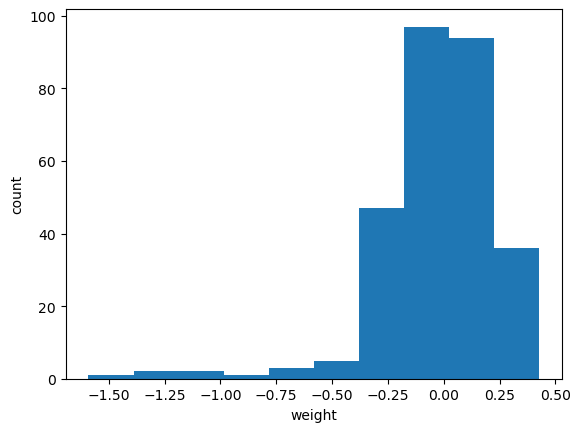

In [6]:
import matplotlib.pyplot as plt

plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

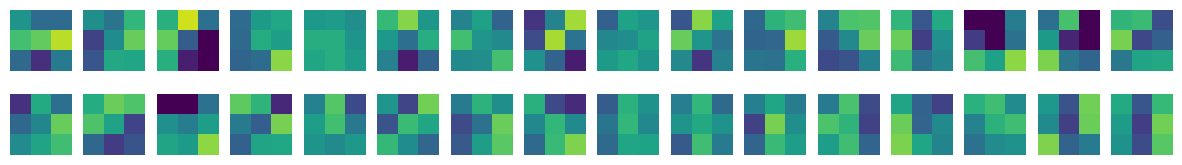

In [7]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

In [8]:
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Input(shape=(28,28,1)))
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu',
                                          padding='same'))

In [9]:
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

(3, 3, 1, 32)


In [10]:
no_training_weights = no_training_conv.weights[0].numpy()
print(no_training_weights.mean(), no_training_weights.std())

-0.010310263 0.0773888


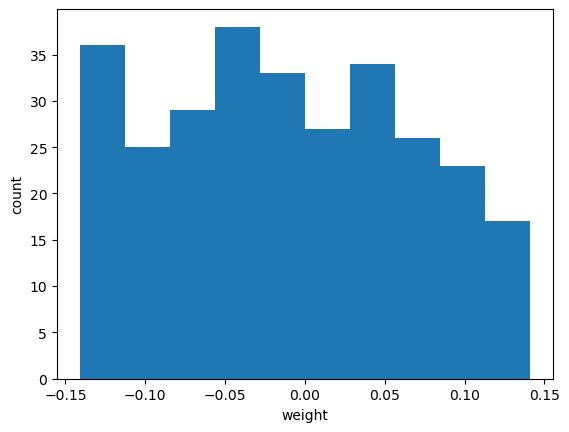

In [11]:
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

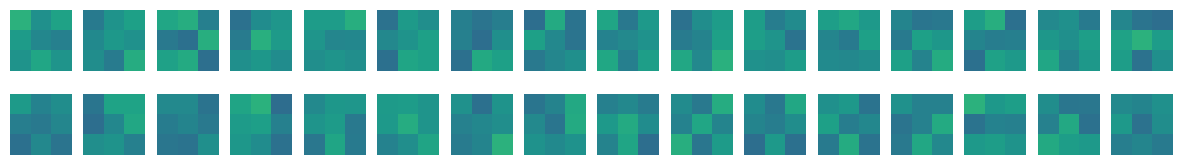

In [12]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_training_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

## 함수형 API

In [13]:
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')

hidden = dense1(inputs)
outputs = dense2(hidden)

func_model = keras.Model(inputs, outputs)

In [14]:
print(model.inputs)

[<KerasTensor: shape=(None, 28, 28, 1) dtype=float32 (created by layer 'input_1')>]


In [15]:
conv_acti = keras.Model(model.inputs[0], model.layers[0].output)

## 특성 맵 시각화

In [16]:
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()

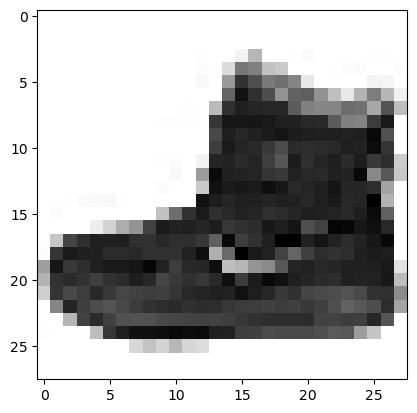

In [17]:
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

In [18]:
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1)/255.0
feature_maps = conv_acti.predict(ankle_boot)

1/1 [==============================] - 0s 118ms/step


In [19]:
print(feature_maps.shape)

(1, 28, 28, 32)


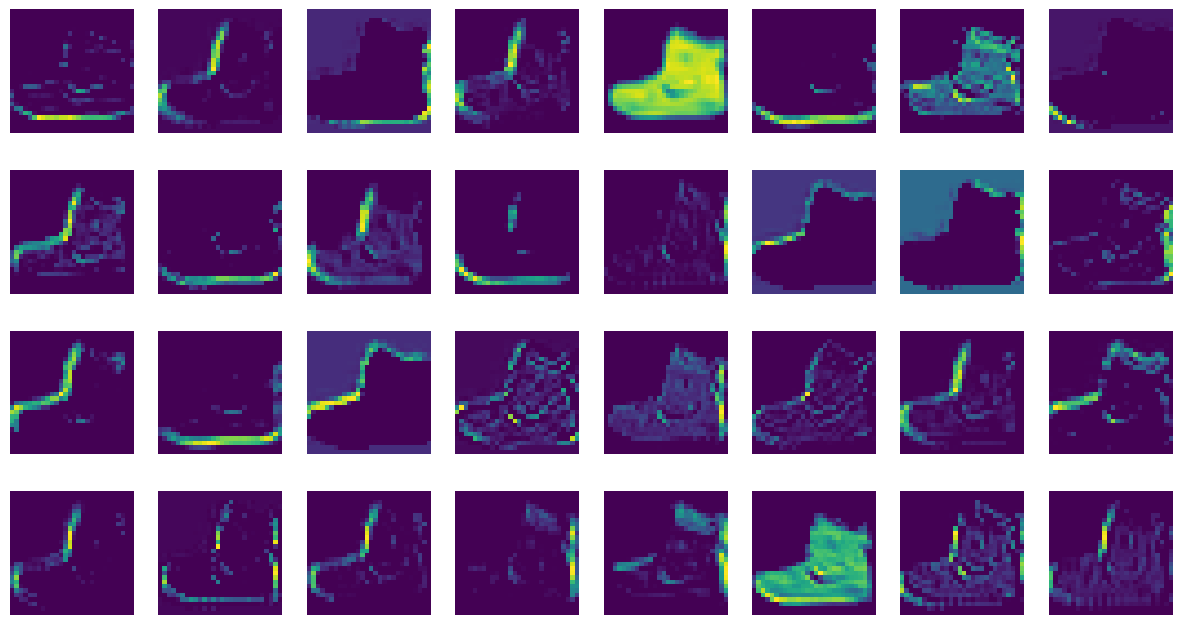

In [20]:
fig, axs = plt.subplots(4, 8, figsize=(15,8))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')
plt.show()

In [21]:
conv2_acti = keras.Model(model.inputs, model.layers[2].output)

In [22]:
feature_maps = conv2_acti.predict(ankle_boot)

1/1 [==============================] - 0s 47ms/step


In [23]:
print(feature_maps.shape)

(1, 14, 14, 64)


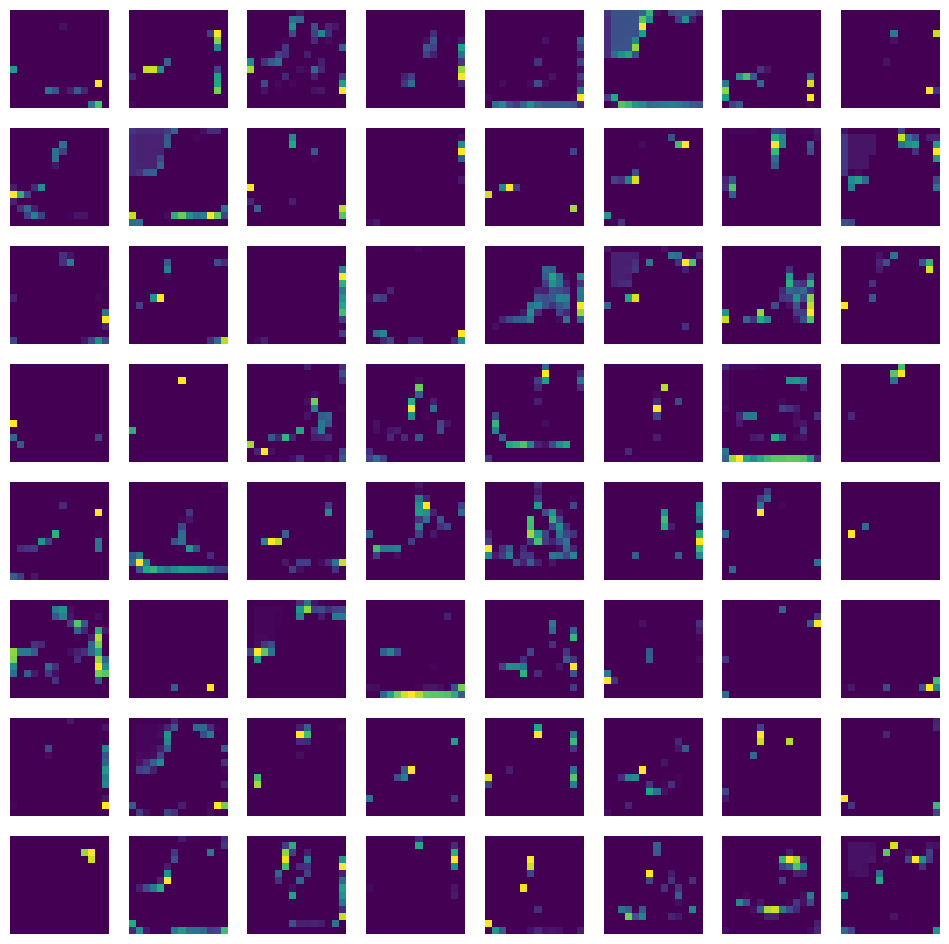

In [24]:
fig, axs = plt.subplots(8, 8, figsize=(12,12))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')
plt.show()